In [ ]:
# ============================================================
# CAS D'ÉTUDE 1 : DÉTECTION AUTOMATIQUE DES DÉFAUTS VERRIERS
# Mémoire : L'IA au Service de la Production et de la Sécurité
#            dans l'Industrie Verrière
# Auteure  : Sedanur
# Dataset  : Glass Defect Detection2 (Roboflow Universe)
#            4 classes : bubble, crack, inclusion, scratch
#            578 images (train:406 / valid:86 / test:86)
# Modèle   : YOLOv8n (Ultralytics)
# ============================================================

In [29]:
# ============================================================
# CELLULE 1 : Installation des bibliothèques
# ============================================================
!pip install ultralytics -q
!pip install roboflow -q
!pip install seaborn matplotlib pandas numpy opencv-python-headless -q
# Installation des librairies nécessaires YOLOv8



import subprocess
subprocess.run(["pip", "install", "grad-cam", "-q"], capture_output=True)

print("Installation terminée")

Installation terminée


In [30]:
import torch
import ultralytics

print("PyTorch :", torch.__version__)
print("CUDA disponible :", torch.cuda.is_available())
print("GPU :", torch.cuda.get_device_name(0))

print("Ultralytics :", ultralytics.__version__)

from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print(" YOLO fonctionne")

PyTorch : 2.11.0+cu128
CUDA disponible : True
GPU : Tesla T4
Ultralytics : 8.4.107
 YOLO fonctionne


In [31]:
import torch
from ultralytics import YOLO

print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cu128
True


In [32]:
import torch

# Install torch and torchvision with the specified CUDA index URL
#!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Torch CUDA version: {torch.version.cuda}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
else:
    print("No CUDA-enabled GPU detected. Please ensure you are using a GPU runtime and the correct PyTorch version is installed.")

CUDA available: True
Torch CUDA version: 12.8
CUDA device name: Tesla T4


In [33]:
# ============================================================
# CELLULE 2 : Imports
# ============================================================

import os
import sys
import glob
import shutil
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
import yaml
import json
from collections import Counter, defaultdict

# Deep Learning
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, models

# YOLO
from ultralytics import YOLO
from ultralytics.utils.plotting import Annotator, colors

# Métriques
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_fscore_support, average_precision_score
)

# Style global
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_palette("husl")

print(f"PyTorch version : {torch.__version__}")
print(f" GPU disponible  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.11.0+cu128
 GPU disponible  : True
   GPU : Tesla T4


In [34]:
# ============================================================
# CELLULE 3 : Upload du dataset depuis votre machine locale
# ============================================================
# OPTION A : Upload manuel depuis votre PC
# Zippez votre dossier "Glass Defect Detection2.yolov8"
# et uploadez le zip ici

from google.colab import files
import zipfile

print(" Uploadez votre fichier ZIP du dataset...")
print("   (Zippez le dossier contenant train/, valid/, test/ et data.yaml)")
print()

# Décommentez pour uploader manuellement :
# uploaded = files.upload()
# zip_name = list(uploaded.keys())[0]
# with zipfile.ZipFile(zip_name, 'r') as zip_ref:
#     zip_ref.extractall('/content/glass_dataset')

# ---- OU OPTION B : Montez Google Drive ----
from google.colab import drive
drive.mount('/content/drive')

# Adaptez ce chemin selon où vous avez mis le dataset sur Drive :
DATASET_DRIVE_PATH = '/content/drive/MyDrive/Glass Defect Detection2.yolov8'

# Copie locale pour accélération
DATASET_PATH = '/content/glass_dataset'
if not os.path.exists(DATASET_PATH):
    shutil.copytree(DATASET_DRIVE_PATH, DATASET_PATH)
    print(f" Dataset copié vers {DATASET_PATH}")
else:
    print(f" Dataset déjà présent dans {DATASET_PATH}")

# Vérification de la structure
print("\n Structure du dataset :")
for split in ['train', 'valid', 'test']:
    img_path = os.path.join(DATASET_PATH, split, 'images')
    lbl_path = os.path.join(DATASET_PATH, split, 'labels')
    if os.path.exists(img_path):
        n_img = len(glob.glob(os.path.join(img_path, '*')))
        n_lbl = len(glob.glob(os.path.join(lbl_path, '*.txt'))) if os.path.exists(lbl_path) else 0
        print(f"   {split:6s} → {n_img:4d} images | {n_lbl:4d} labels")

 Uploadez votre fichier ZIP du dataset...
   (Zippez le dossier contenant train/, valid/, test/ et data.yaml)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Dataset déjà présent dans /content/glass_dataset

 Structure du dataset :
   train  →  406 images |  406 labels
   valid  →   45 images |   86 labels
   test   →   86 images |   86 labels


In [35]:
# ============================================================
# CELLULE 4 : Création du fichier data.yaml pour YOLOv8
# ============================================================

DATA_YAML_PATH = os.path.join(DATASET_PATH, 'data.yaml')

# Contenu du fichier YAML
data_yaml_content = {
    'path': DATASET_PATH,
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc': 4,
    'names': ['bubble', 'crack', 'inclusion', 'scratch']
}

with open(DATA_YAML_PATH, 'w') as f:
    yaml.dump(data_yaml_content, f, default_flow_style=False, allow_unicode=True)

print(" Fichier data.yaml créé :")
print("-" * 40)
with open(DATA_YAML_PATH, 'r') as f:
    print(f.read())
print("-" * 40)

# Constantes globales
CLASSES     = ['bubble', 'crack', 'inclusion', 'scratch']
CLASS_COLORS = {
    'bubble':    '#FF6B6B',   # Rouge
    'crack':     '#4ECDC4',   # Cyan
    'inclusion': '#45B7D1',   # Bleu
    'scratch':   '#96CEB4'    # Vert
}
NC = 4

 Fichier data.yaml créé :
----------------------------------------
names:
- bubble
- crack
- inclusion
- scratch
nc: 4
path: /content/glass_dataset
test: test/images
train: train/images
val: valid/images

----------------------------------------


In [36]:
# ============================================================
# CELLULE 5 : Analyse Exploratoire des Données (EDA)
# ============================================================

def parse_yolo_labels(dataset_path, splits=['train', 'valid', 'test']):
    """
    Parse tous les fichiers labels YOLO et retourne un DataFrame.
    Format YOLO : class_id cx cy w h (normalisé)
    """
    records = []
    for split in splits:
        label_dir = os.path.join(dataset_path, split, 'labels')
        image_dir = os.path.join(dataset_path, split, 'images')
        if not os.path.exists(label_dir):
            continue
        for lbl_file in glob.glob(os.path.join(label_dir, '*.txt')):
            img_name = os.path.splitext(os.path.basename(lbl_file))[0]
            # Cherche l'image correspondante
            img_file = None
            for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
                candidate = os.path.join(image_dir, img_name + ext)
                if os.path.exists(candidate):
                    img_file = candidate
                    break
            with open(lbl_file, 'r') as f:
                lines = f.readlines()
            if len(lines) == 0:
                # Image sans défaut (background)
                records.append({
                    'split': split, 'image': img_name,
                    'class_id': -1, 'class_name': 'background',
                    'cx': None, 'cy': None, 'w': None, 'h': None,
                    'area': None, 'image_path': img_file
                })
            else:
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cid = int(parts[0])
                        cx, cy, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                        records.append({
                            'split': split, 'image': img_name,
                            'class_id': cid,
                            'class_name': CLASSES[cid] if cid < NC else 'unknown',
                            'cx': cx, 'cy': cy, 'w': w, 'h': h,
                            'area': w * h,
                            'image_path': img_file
                        })
    return pd.DataFrame(records)

# Parsing
df_labels = parse_yolo_labels(DATASET_PATH)
df_defects = df_labels[df_labels['class_id'] >= 0].copy()

print(f" Total annotations parsées : {len(df_labels)}")
print(f"   Défauts annotés           : {len(df_defects)}")
print(f"   Images uniques            : {df_labels['image'].nunique()}")
print()
print("Distribution par split et classe :")
print(df_defects.groupby(['split', 'class_name']).size().unstack(fill_value=0))

 Total annotations parsées : 1511
   Défauts annotés           : 1355
   Images uniques            : 578

Distribution par split et classe :
class_name  bubble  crack  inclusion  scratch
split                                        
test            20     42         22      144
train           90    191        117      515
valid           19     57         35      103


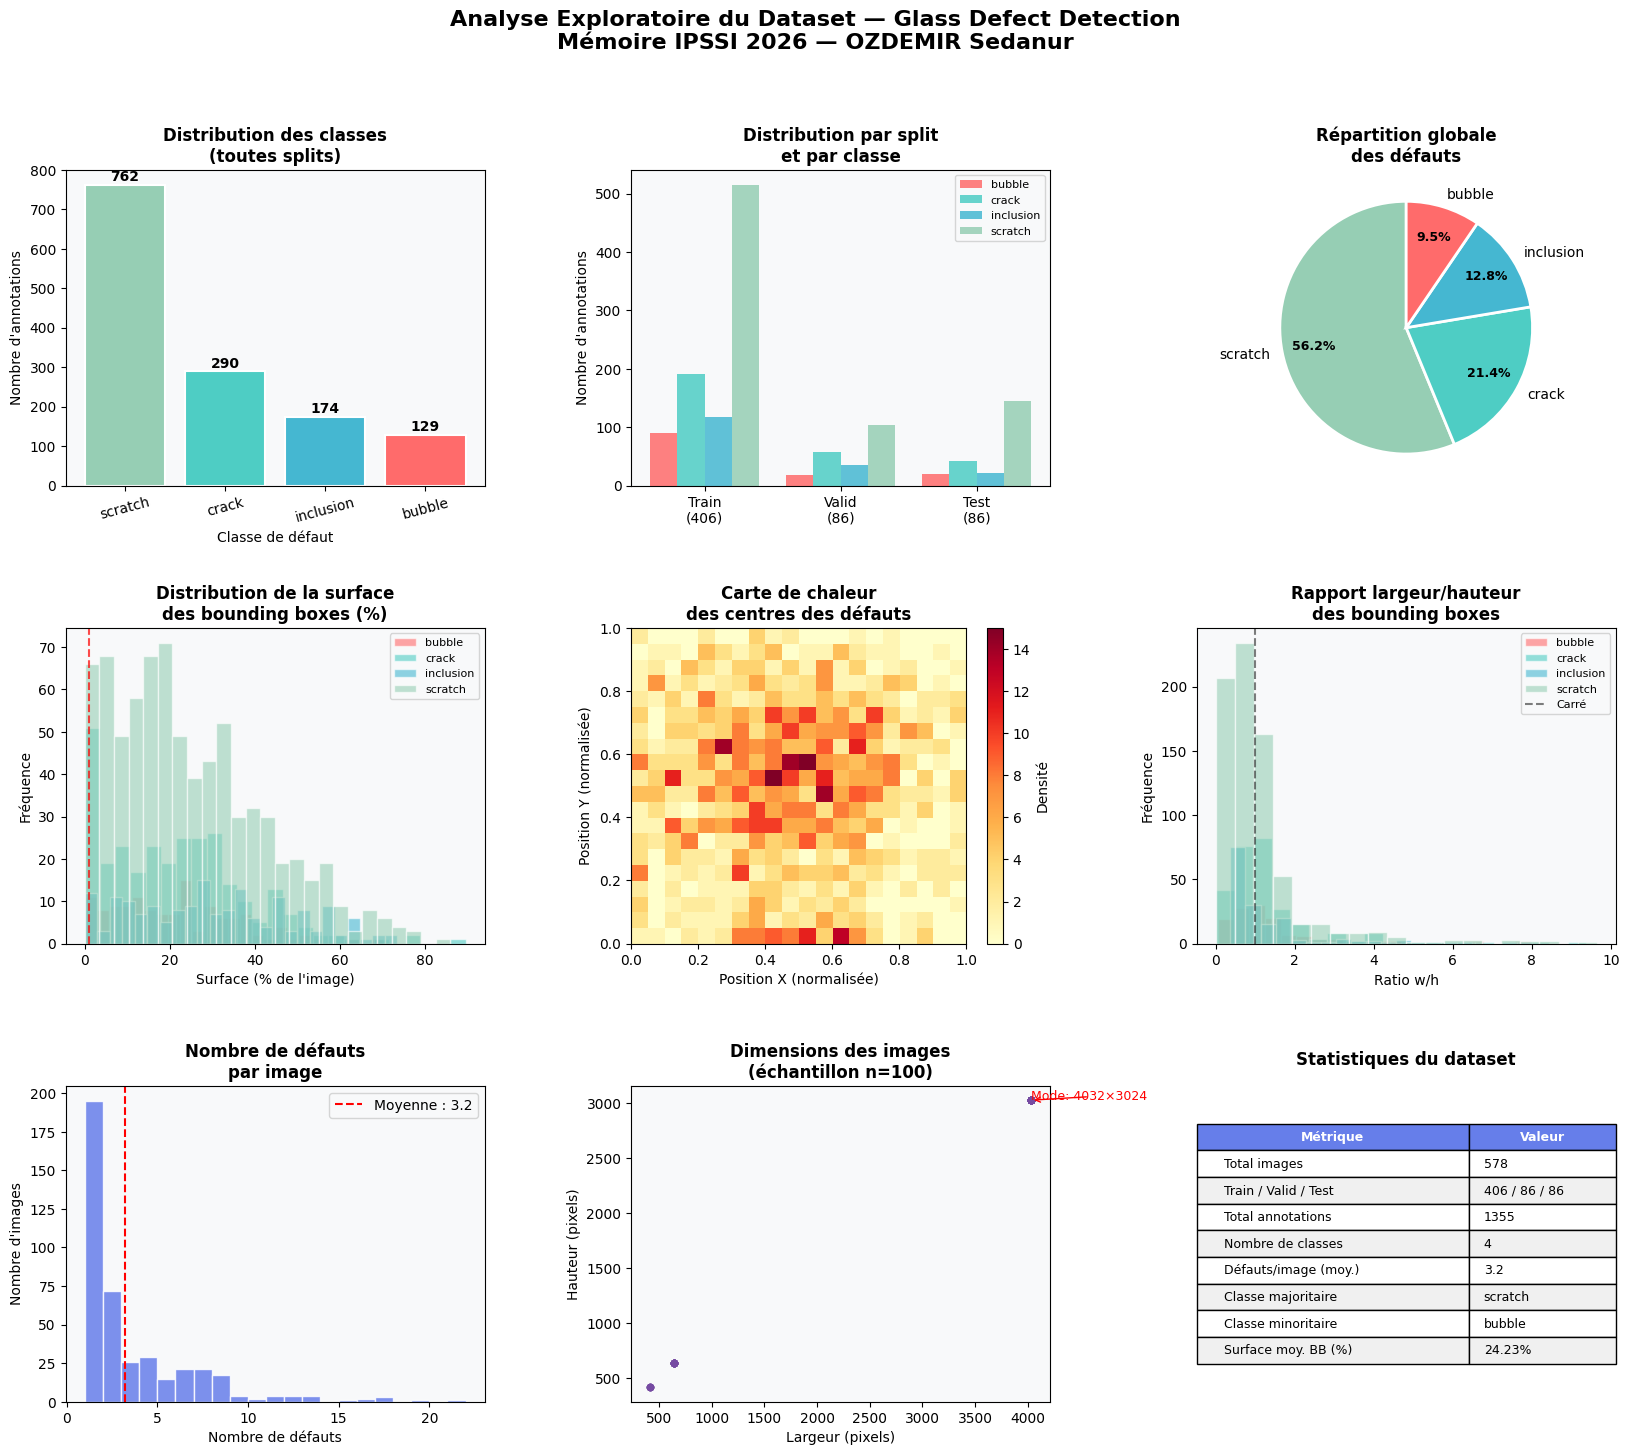

 Figure EDA sauvegardée : /content/fig_eda_dataset.png


In [37]:
# ============================================================
# CELLULE 5b : Visualisations EDA
# ============================================================

fig = plt.figure(figsize=(20, 16))
fig.suptitle(
    "Analyse Exploratoire du Dataset — Glass Defect Detection\n"
    "Mémoire IPSSI 2026 — OZDEMIR Sedanur",
    fontsize=16, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Figure 1 : Distribution des classes (toutes splits) ──────────────────
ax1 = fig.add_subplot(gs[0, 0])
class_counts = df_defects['class_name'].value_counts()
bars = ax1.bar(class_counts.index, class_counts.values,
               color=[CLASS_COLORS[c] for c in class_counts.index],
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.set_title('Distribution des classes\n(toutes splits)', fontweight='bold')
ax1.set_xlabel('Classe de défaut')
ax1.set_ylabel('Nombre d\'annotations')
ax1.tick_params(axis='x', rotation=15)

# ── Figure 2 : Distribution par split ────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
split_class = df_defects.groupby(['split', 'class_name']).size().unstack(fill_value=0)
split_class = split_class.reindex(['train', 'valid', 'test'])
x = np.arange(len(split_class.index))
width = 0.2
for i, cls in enumerate(CLASSES):
    if cls in split_class.columns:
        ax2.bar(x + i*width, split_class[cls], width,
                label=cls, color=CLASS_COLORS[cls], alpha=0.85)
ax2.set_xticks(x + width*1.5)
ax2.set_xticklabels(['Train\n(406)', 'Valid\n(86)', 'Test\n(86)'])
ax2.set_title('Distribution par split\net par classe', fontweight='bold')
ax2.set_ylabel('Nombre d\'annotations')
ax2.legend(fontsize=8)

# ── Figure 3 : Camembert de la répartition globale ───────────────────────
ax3 = fig.add_subplot(gs[0, 2])
wedge_colors = [CLASS_COLORS[c] for c in class_counts.index]
wedges, texts, autotexts = ax3.pie(
    class_counts.values, labels=class_counts.index,
    colors=wedge_colors, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
ax3.set_title('Répartition globale\ndes défauts', fontweight='bold')

# ── Figure 4 : Distribution de la surface des bounding boxes ─────────────
ax4 = fig.add_subplot(gs[1, 0])
for cls in CLASSES:
    subset = df_defects[df_defects['class_name'] == cls]['area'].dropna()
    if len(subset) > 0:
        ax4.hist(subset * 100, bins=25, alpha=0.6,
                 label=cls, color=CLASS_COLORS[cls], edgecolor='white')
ax4.set_title('Distribution de la surface\ndes bounding boxes (%)', fontweight='bold')
ax4.set_xlabel('Surface (% de l\'image)')
ax4.set_ylabel('Fréquence')
ax4.legend(fontsize=8)
ax4.axvline(x=1, color='red', linestyle='--', alpha=0.7, label='Seuil 1%')

# ── Figure 5 : Carte de chaleur des centres des défauts ──────────────────
ax5 = fig.add_subplot(gs[1, 1])
cx_vals = df_defects['cx'].dropna().values
cy_vals = df_defects['cy'].dropna().values
if len(cx_vals) > 0:
    h, xedges, yedges = np.histogram2d(cx_vals, cy_vals, bins=20,
                                        range=[[0,1],[0,1]])
    im = ax5.imshow(h.T, origin='lower', aspect='auto',
                    extent=[0,1,0,1], cmap='YlOrRd')
    plt.colorbar(im, ax=ax5, label='Densité')
ax5.set_title('Carte de chaleur\ndes centres des défauts', fontweight='bold')
ax5.set_xlabel('Position X (normalisée)')
ax5.set_ylabel('Position Y (normalisée)')

# ── Figure 6 : Rapport largeur/hauteur des bounding boxes ────────────────
ax6 = fig.add_subplot(gs[1, 2])
for cls in CLASSES:
    subset = df_defects[df_defects['class_name'] == cls]
    ratio = (subset['w'] / subset['h']).dropna()
    ratio = ratio[(ratio > 0) & (ratio < 10)]
    if len(ratio) > 0:
        ax6.hist(ratio, bins=20, alpha=0.6,
                 label=cls, color=CLASS_COLORS[cls], edgecolor='white')
ax6.set_title('Rapport largeur/hauteur\ndes bounding boxes', fontweight='bold')
ax6.set_xlabel('Ratio w/h')
ax6.set_ylabel('Fréquence')
ax6.axvline(x=1, color='black', linestyle='--', alpha=0.5, label='Carré')
ax6.legend(fontsize=8)

# ── Figure 7 : Nombre de défauts par image ───────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
defects_per_img = df_defects.groupby('image').size()
ax7.hist(defects_per_img.values, bins=range(1, defects_per_img.max()+2),
         color='#667eea', edgecolor='white', alpha=0.85)
ax7.set_title('Nombre de défauts\npar image', fontweight='bold')
ax7.set_xlabel('Nombre de défauts')
ax7.set_ylabel('Nombre d\'images')
ax7.axvline(defects_per_img.mean(), color='red', linestyle='--',
            label=f'Moyenne : {defects_per_img.mean():.1f}')
ax7.legend()

# ── Figure 8 : Taille des images ─────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 1])
widths, heights = [], []
sample_imgs = df_defects['image_path'].dropna().unique()[:100]
for img_path in sample_imgs:
    try:
        img = Image.open(img_path)
        widths.append(img.width)
        heights.append(img.height)
    except:
        pass
if widths:
    ax8.scatter(widths, heights, alpha=0.5, color='#764ba2', s=20)
    ax8.set_title(f'Dimensions des images\n(échantillon n={len(widths)})', fontweight='bold')
    ax8.set_xlabel('Largeur (pixels)')
    ax8.set_ylabel('Hauteur (pixels)')
    # Annotation de la taille la plus fréquente
    from collections import Counter
    size_counter = Counter(zip(widths, heights))
    most_common = size_counter.most_common(1)[0]
    ax8.annotate(f'Mode: {most_common[0][0]}×{most_common[0][1]}',
                 xy=most_common[0], fontsize=9, color='red',
                 arrowprops=dict(arrowstyle='->', color='red'))

# ── Figure 9 : Statistiques résumées ─────────────────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')
stats_data = {
    'Métrique': [
        'Total images', 'Train / Valid / Test',
        'Total annotations', 'Nombre de classes',
        'Défauts/image (moy.)', 'Classe majoritaire',
        'Classe minoritaire', 'Surface moy. BB (%)'
    ],
    'Valeur': [
        str(df_labels['image'].nunique()),
        '406 / 86 / 86',
        str(len(df_defects)),
        '4',
        f"{df_defects.groupby('image').size().mean():.1f}",
        class_counts.idxmax(),
        class_counts.idxmin(),
        f"{df_defects['area'].mean()*100:.2f}%"
    ]
}
table = ax9.table(
    cellText=list(zip(stats_data['Métrique'], stats_data['Valeur'])),
    colLabels=['Métrique', 'Valeur'],
    cellLoc='left', loc='center',
    colWidths=[0.65, 0.35]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#667eea')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f0f0f0')
ax9.set_title('Statistiques du dataset', fontweight='bold', pad=15)

plt.savefig('/content/fig_eda_dataset.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print(" Figure EDA sauvegardée : /content/fig_eda_dataset.png")

 Visualisation d'exemples par classe de défaut...


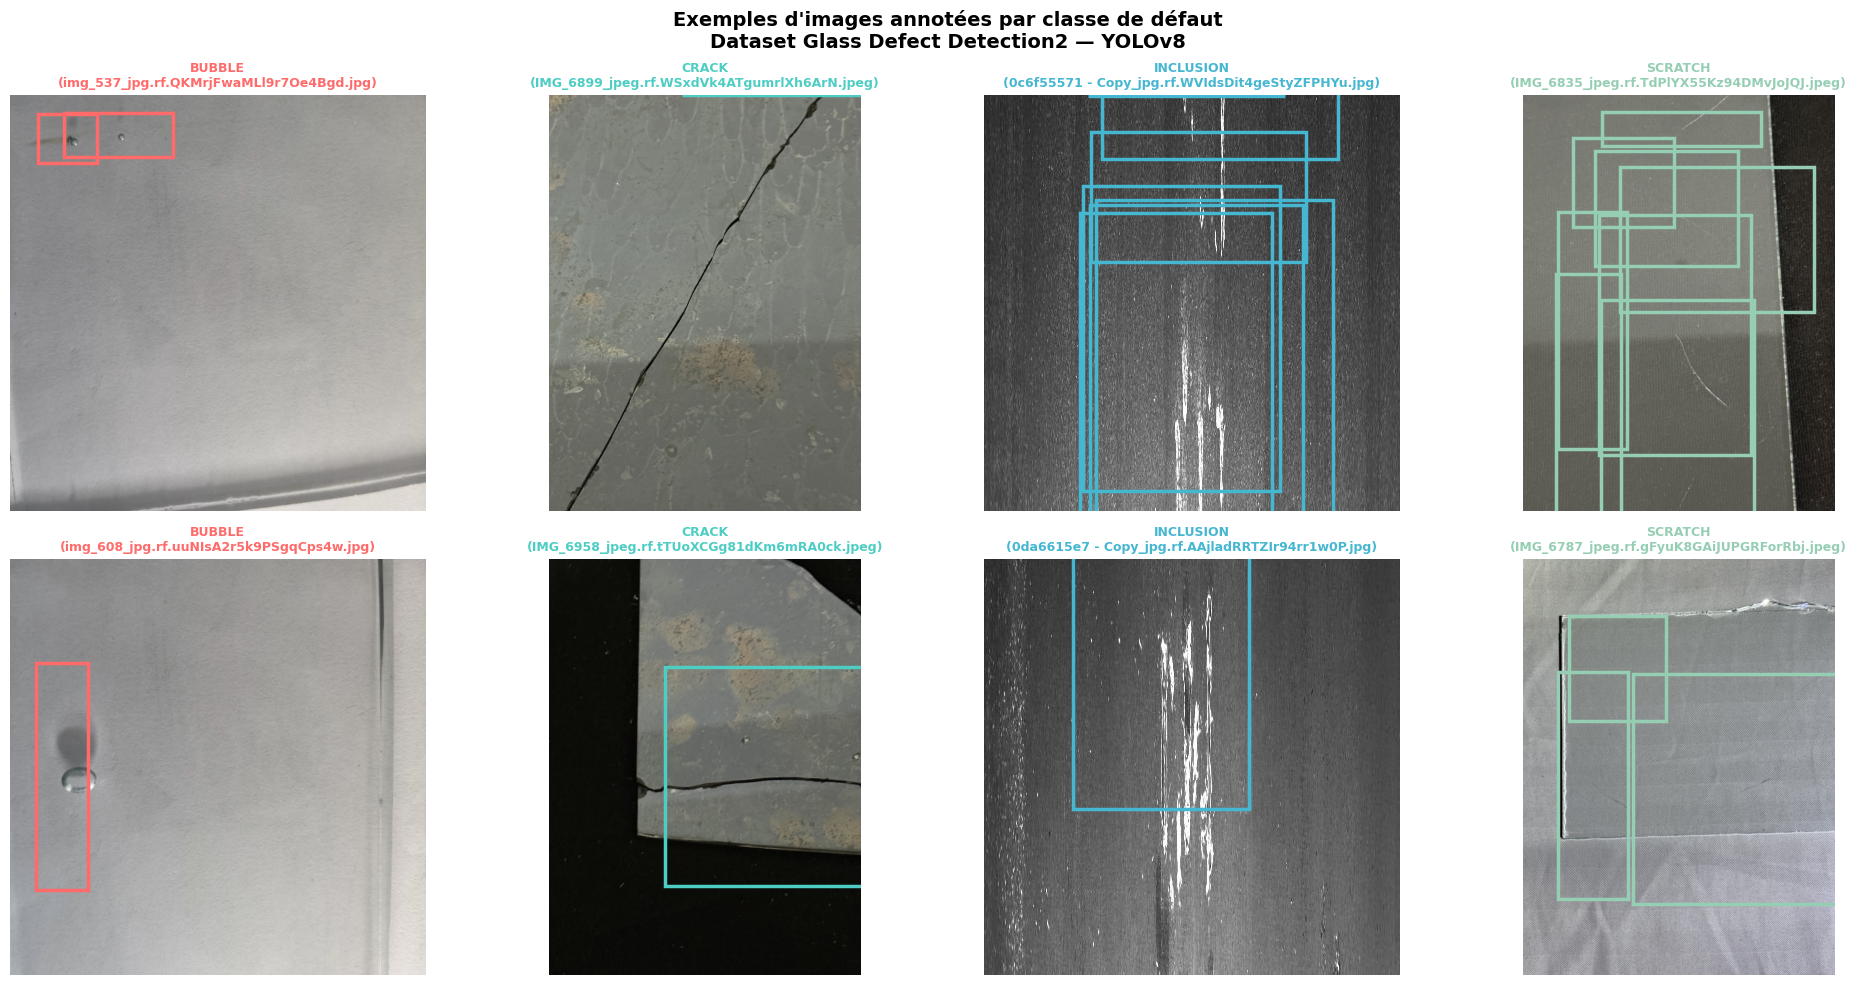

 Figure exemples sauvegardée


In [38]:
# ============================================================
# CELLULE 6 : Visualisation d'exemples d'images annotées
# ============================================================

def draw_yolo_boxes(image_path, label_path, classes, class_colors, figsize=(8, 6)):
    """Affiche une image avec ses bounding boxes YOLO."""
    img = cv2.imread(image_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(img)

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                cid = int(parts[0])
                cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                # Conversion vers pixels
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                bw_px = int(bw * w)
                bh_px = int(bh * h)
                cls_name = classes[cid] if cid < len(classes) else 'unknown'
                color = class_colors.get(cls_name, '#ffffff')
                rect = patches.Rectangle(
                    (x1, y1), bw_px, bh_px,
                    linewidth=2.5, edgecolor=color, facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(x1, y1 - 5, cls_name.upper(),
                        color='white', fontsize=9, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.85))
    ax.axis('off')
    return fig

# Affichage d'une grille d'exemples par classe
print(" Visualisation d'exemples par classe de défaut...")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(
    "Exemples d'images annotées par classe de défaut\nDataset Glass Defect Detection2 — YOLOv8",
    fontsize=14, fontweight='bold'
)

for col_idx, cls_name in enumerate(CLASSES):
    # Cherche des images contenant cette classe
    cls_images = df_defects[df_defects['class_name'] == cls_name]['image_path'].dropna().unique()

    for row_idx in range(2):
        ax = axes[row_idx, col_idx]
        if row_idx < len(cls_images):
            img_path = cls_images[row_idx]
            lbl_path = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'

            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                h, w = img.shape[:2]
                ax.imshow(img)

                if os.path.exists(lbl_path):
                    with open(lbl_path, 'r') as f:
                        lines = f.readlines()
                    for line in lines:
                        parts = line.strip().split()
                        if len(parts) >= 5 and int(parts[0]) == CLASSES.index(cls_name):
                            cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                            x1 = int((cx - bw/2) * w)
                            y1 = int((cy - bh/2) * h)
                            rect = patches.Rectangle(
                                (x1, y1), int(bw*w), int(bh*h),
                                linewidth=2.5, edgecolor=CLASS_COLORS[cls_name],
                                facecolor='none'
                            )
                            ax.add_patch(rect)

                ax.set_title(f'{cls_name.upper()}\n({os.path.basename(img_path)})',
                             fontsize=9, color=CLASS_COLORS[cls_name], fontweight='bold')
            else:
                ax.text(0.5, 0.5, 'Image\nnon disponible',
                        ha='center', va='center', transform=ax.transAxes)
        else:
            ax.text(0.5, 0.5, f'Pas d\'exemple\ndisponible',
                    ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.savefig('/content/fig_exemples_classes.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print(" Figure exemples sauvegardée")

In [39]:
# ============================================================
# CELLULE 7 : Entraînement YOLOv8n
# ============================================================

from ultralytics import YOLO
import os

MODEL_SIZE = "n"  # n, s, m, l, x

model = YOLO(f"yolov8{MODEL_SIZE}.pt")


# Paramètres d'entraînement
EPOCHS      = 100
IMG_SIZE    = 640
BATCH_SIZE  = 16

PROJECT_DIR = "/content/glass_defect_runs"
RUN_NAME    = "yolov8n_glass_defect_v1"

print("Modèle YOLO chargé")

Modèle YOLO chargé


In [40]:
# ============================================================
# CELLULE 7 : Entraînement YOLOv8n
# ============================================================



# Entraînement
results = model.train(
    data=DATA_YAML_PATH,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=0,              # GPU Tesla T4
    project=PROJECT_DIR,
    name=RUN_NAME
)


# Chemin du meilleur modèle sauvegardé
BEST_MODEL_PATH = os.path.join(
    PROJECT_DIR,
    RUN_NAME,
    'weights',
    'best.pt'
)

print("\n✅ Entraînement terminé !")
print(f"🏆 Meilleur modèle : {BEST_MODEL_PATH}")

if os.path.exists(BEST_MODEL_PATH):
    print("✅ best.pt existe bien")
else:
    print("⚠️ best.pt non trouvé")

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/glass_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_glass_defect_v1-2, 

Colonnes disponibles : ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


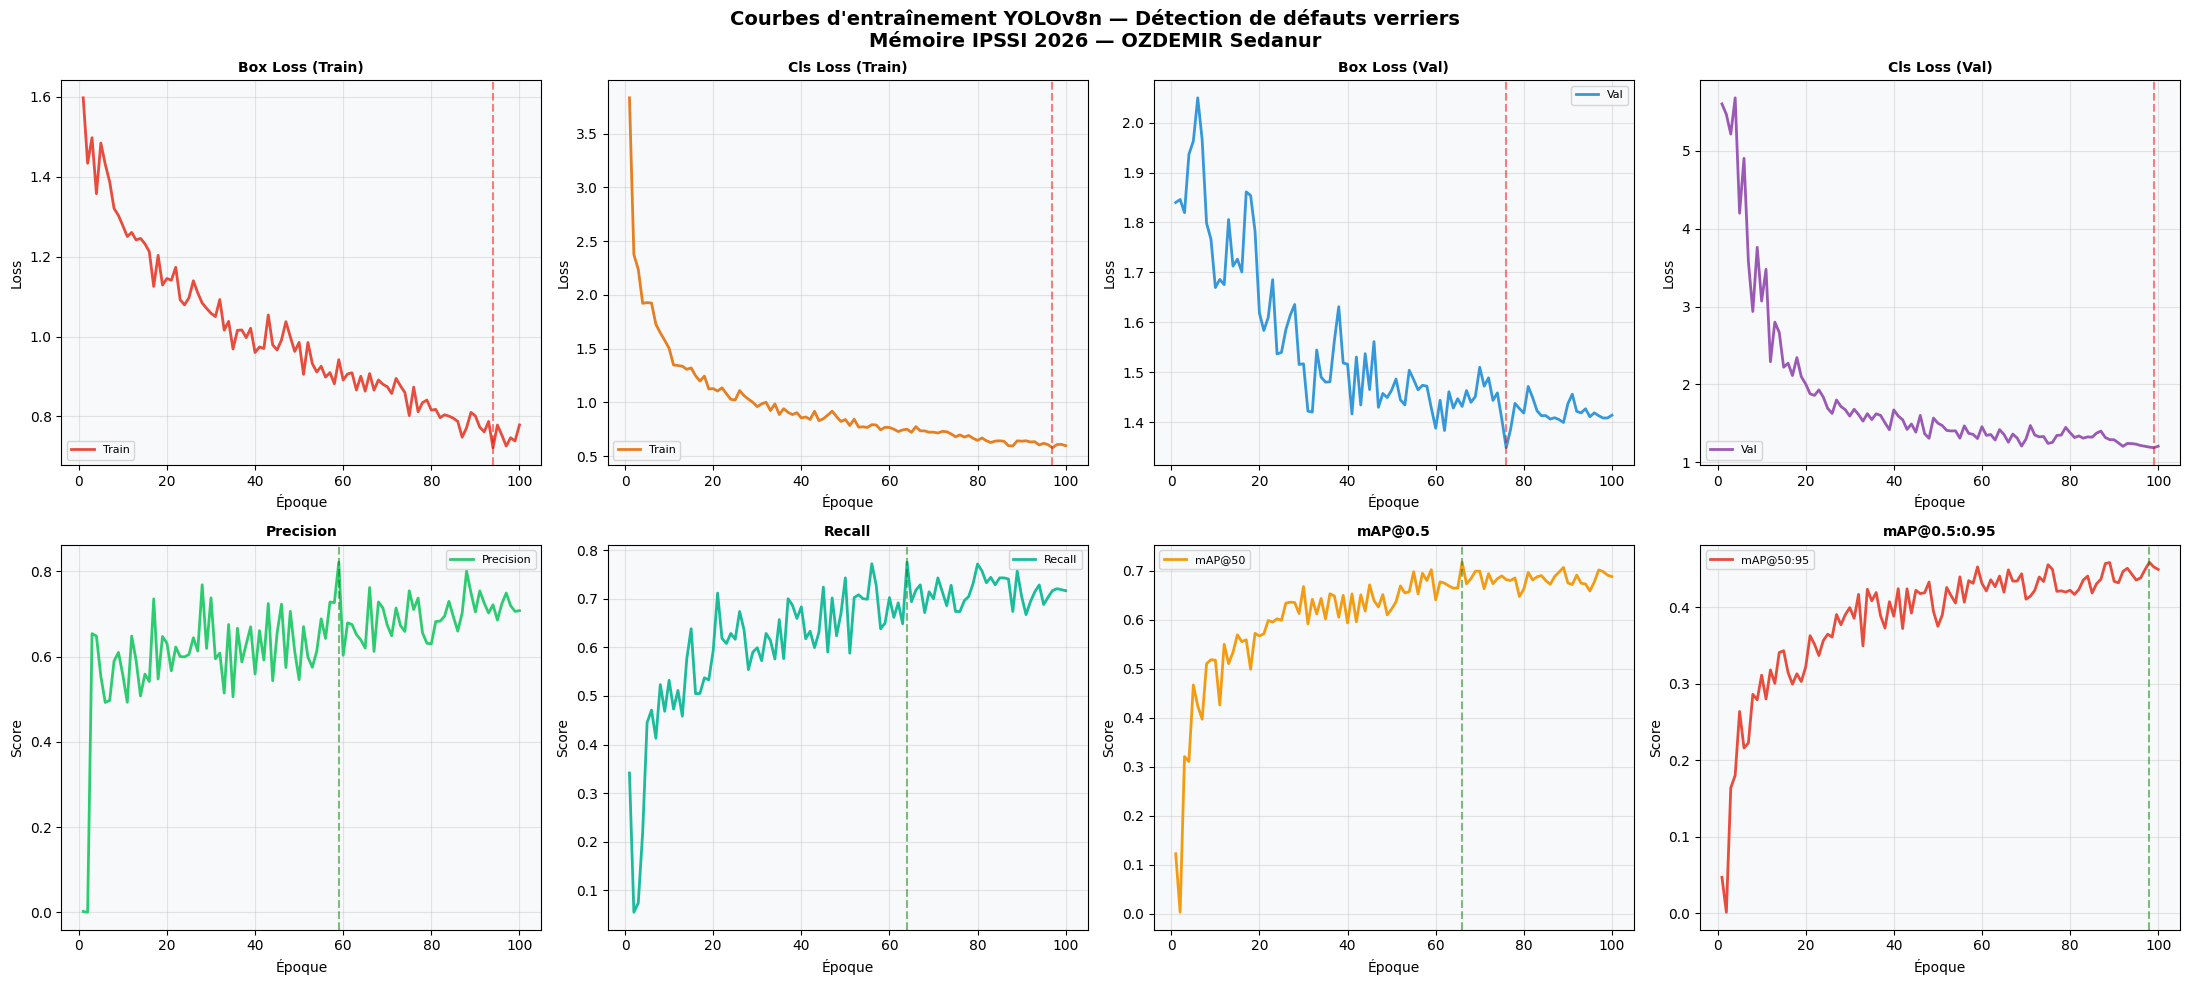


 Meilleures métriques obtenues :
---------------------------------------------
   mAP@0.5         : 0.7173  (époque 66)
   mAP@0.5:0.95    : 0.4591  (époque 98)
   Precision       : 0.8210  (époque 59)
   Recall          : 0.7749  (époque 64)
---------------------------------------------


In [41]:
# ============================================================
# CELLULE 8 : Visualisation des courbes d'entraînement
# ============================================================

results_dir = os.path.join(PROJECT_DIR, RUN_NAME)
results_csv = os.path.join(results_dir, 'results.csv')

if os.path.exists(results_csv):
    df_results = pd.read_csv(results_csv)
    df_results.columns = df_results.columns.str.strip()

    print("Colonnes disponibles :", list(df_results.columns))

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    fig.suptitle(
        "Courbes d'entraînement YOLOv8n — Détection de défauts verriers\n"
        "Mémoire IPSSI 2026 — OZDEMIR Sedanur",
        fontsize=14, fontweight='bold'
    )

    epochs_range = range(1, len(df_results) + 1)

    # Mapping des colonnes YOLO v8
    col_map = {
        'box_loss_train': 'train/box_loss',
        'cls_loss_train': 'train/cls_loss',
        'dfl_loss_train': 'train/dfl_loss',
        'box_loss_val':   'val/box_loss',
        'cls_loss_val':   'val/cls_loss',
        'dfl_loss_val':   'val/dfl_loss',
        'precision':      'metrics/precision(B)',
        'recall':         'metrics/recall(B)',
        'mAP50':          'metrics/mAP50(B)',
        'mAP50_95':       'metrics/mAP50-95(B)',
    }

    def safe_plot(ax, col_name, label, color, title, ylabel):
        """Plot sécurisé avec gestion des colonnes manquantes."""
        if col_name in df_results.columns:
            vals = pd.to_numeric(df_results[col_name], errors='coerce')
            ax.plot(epochs_range, vals, color=color, linewidth=2, label=label)
            ax.set_title(title, fontweight='bold', fontsize=10)
            ax.set_xlabel('Époque')
            ax.set_ylabel(ylabel)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            # Marquer le minimum/maximum
            if not vals.isna().all():
                if 'loss' in ylabel.lower():
                    best_ep = vals.idxmin() + 1
                    ax.axvline(best_ep, color='red', linestyle='--', alpha=0.5,
                               label=f'Min: ép.{best_ep}')
                else:
                    best_ep = vals.idxmax() + 1
                    ax.axvline(best_ep, color='green', linestyle='--', alpha=0.5,
                               label=f'Max: ép.{best_ep}')
        else:
            ax.text(0.5, 0.5, f'Colonne\n"{col_name}"\nnon trouvée',
                    ha='center', va='center', transform=ax.transAxes, fontsize=9)
            ax.set_title(title, fontweight='bold', fontsize=10)

    # Ligne 1 : Losses
    safe_plot(axes[0,0], col_map['box_loss_train'], 'Train', '#e74c3c',
              'Box Loss (Train)', 'Loss')
    safe_plot(axes[0,1], col_map['cls_loss_train'], 'Train', '#e67e22',
              'Cls Loss (Train)', 'Loss')
    safe_plot(axes[0,2], col_map['box_loss_val'],   'Val',   '#3498db',
              'Box Loss (Val)', 'Loss')
    safe_plot(axes[0,3], col_map['cls_loss_val'],   'Val',   '#9b59b6',
              'Cls Loss (Val)', 'Loss')

    # Ligne 2 : Métriques
    safe_plot(axes[1,0], col_map['precision'], 'Precision', '#2ecc71',
              'Precision', 'Score')
    safe_plot(axes[1,1], col_map['recall'],    'Recall',    '#1abc9c',
              'Recall', 'Score')
    safe_plot(axes[1,2], col_map['mAP50'],     'mAP@50',    '#f39c12',
              'mAP@0.5', 'Score')
    safe_plot(axes[1,3], col_map['mAP50_95'],  'mAP@50:95', '#e74c3c',
              'mAP@0.5:0.95', 'Score')

    plt.tight_layout()
    plt.savefig('/content/fig_courbes_entrainement.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()

    # Résumé des meilleures métriques
    print("\n Meilleures métriques obtenues :")
    print("-" * 45)
    for metric_name, col in [
        ('mAP@0.5',      col_map['mAP50']),
        ('mAP@0.5:0.95', col_map['mAP50_95']),
        ('Precision',    col_map['precision']),
        ('Recall',       col_map['recall']),
    ]:
        if col in df_results.columns:
            vals = pd.to_numeric(df_results[col], errors='coerce')
            best_val = vals.max()
            best_ep  = vals.idxmax() + 1
            print(f"   {metric_name:15s} : {best_val:.4f}  (époque {best_ep})")
    print("-" * 45)
else:
    print("  Fichier results.csv non trouvé. Vérifiez le chemin du run.")
    print(f"   Chemin cherché : {results_csv}")

In [42]:
# ============================================================
# CELLULE 9 : Évaluation sur le jeu de TEST
# ============================================================

print(" Évaluation du modèle sur le jeu de test...")
print("=" * 60)

# Chargement du meilleur modèle
model_eval = YOLO(BEST_MODEL_PATH)

# Évaluation officielle YOLO sur le test set
metrics = model_eval.val(
    data=DATA_YAML_PATH,
    split='test',
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    conf=0.25,
    iou=0.5,
    device=0 if torch.cuda.is_available() else 'cpu',
    verbose=True,
    plots=True,
    save_json=True,
    project=PROJECT_DIR,
    name=RUN_NAME + '_test_eval'
)

print("\n" + "=" * 60)
print("  RÉSULTATS D'ÉVALUATION — JEU DE TEST")
print("=" * 60)
print(f"  mAP@0.5       : {metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95  : {metrics.box.map:.4f}")
print(f"  Precision     : {metrics.box.mp:.4f}")
print(f"  Recall        : {metrics.box.mr:.4f}")
print("=" * 60)

# Métriques par classe
print("\n Métriques par classe :")
print(f"{'Classe':12s} {'AP@0.5':>10s} {'Precision':>10s} {'Recall':>10s}")
print("-" * 45)
for i, cls_name in enumerate(CLASSES):
    try:
        ap50 = metrics.box.ap50[i]
        prec = metrics.box.p[i]
        rec  = metrics.box.r[i]
        print(f"  {cls_name:10s} {ap50:>10.4f} {prec:>10.4f} {rec:>10.4f}")
    except (IndexError, AttributeError):
        print(f"  {cls_name:10s}    N/A")
print("-" * 45)

 Évaluation du modèle sur le jeu de test...
Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 142.1±91.2 MB/s, size: 2122.4 KB)
val: Scanning /content/glass_dataset/test/labels... 86 images, 23 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 86/86 540.5it/s 0.2s
val: New cache created: /content/glass_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.7s/it 10.0s
                   all         86        228      0.792      0.705      0.678      0.534
                bubble         16         20      0.952          1      0.995      0.707
                 crack         22         42      0.837      0.857      0.836      0.721
             inclusion          7         22      0.615      0.364      0.293      0.243
               scratch         1

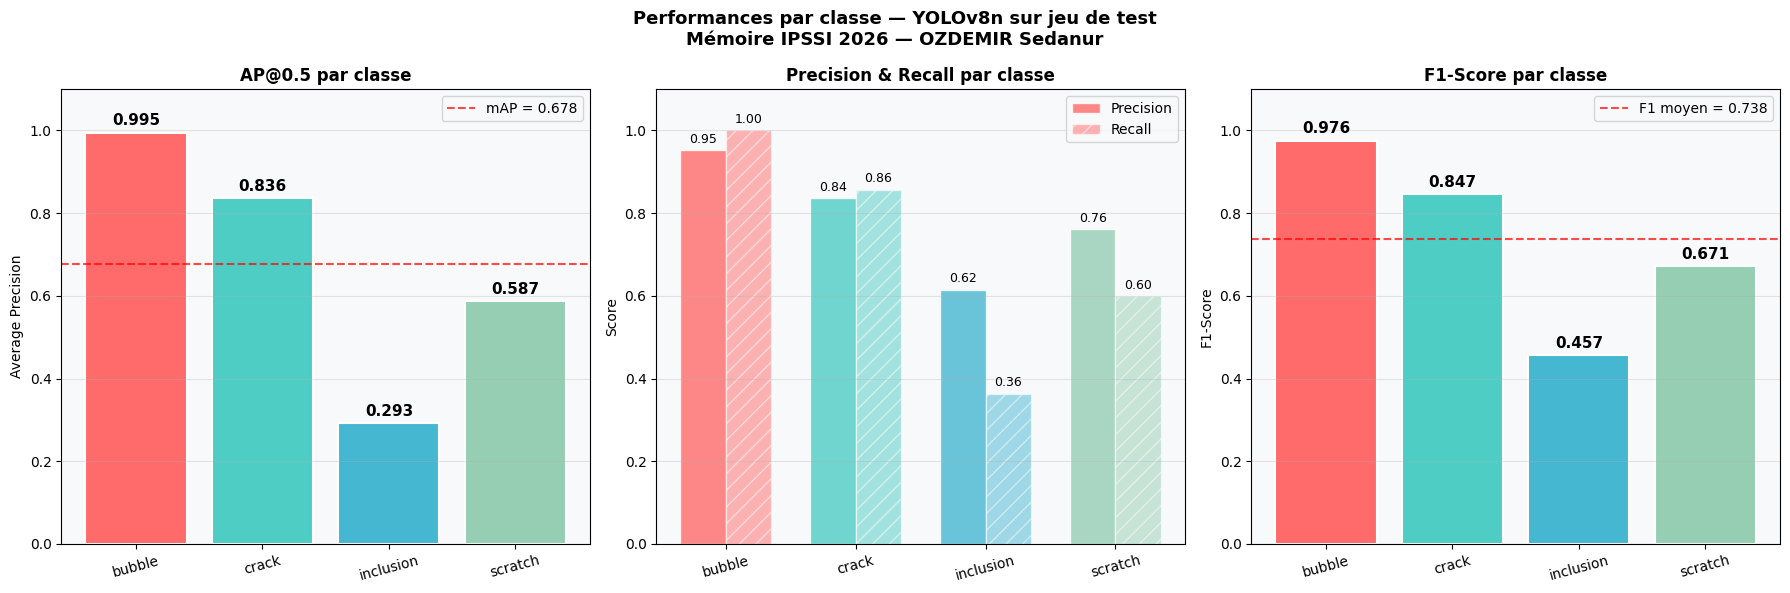

 Figure métriques par classe sauvegardée


In [43]:
# ============================================================
# CELLULE 10 : Visualisation des métriques par classe
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Performances par classe — YOLOv8n sur jeu de test\n"
    "Mémoire IPSSI 2026 — OZDEMIR Sedanur",
    fontsize=13, fontweight='bold'
)

# Extraction des métriques par classe
try:
    ap50_per_class  = metrics.box.ap50
    prec_per_class  = metrics.box.p
    rec_per_class   = metrics.box.r
    f1_per_class    = [2*p*r/(p+r) if (p+r) > 0 else 0
                       for p, r in zip(prec_per_class, rec_per_class)]

    x = np.arange(len(CLASSES))
    bar_colors = [CLASS_COLORS[c] for c in CLASSES]

    # AP@0.5
    bars1 = axes[0].bar(x, ap50_per_class, color=bar_colors,
                        edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars1, ap50_per_class):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom',
                     fontweight='bold', fontsize=11)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(CLASSES, rotation=15)
    axes[0].set_ylim(0, 1.1)
    axes[0].set_title('AP@0.5 par classe', fontweight='bold')
    axes[0].set_ylabel('Average Precision')
    axes[0].axhline(y=np.mean(ap50_per_class), color='red',
                    linestyle='--', alpha=0.7,
                    label=f'mAP = {np.mean(ap50_per_class):.3f}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')

    # Precision & Recall
    width = 0.35
    bars_p = axes[1].bar(x - width/2, prec_per_class, width,
                         label='Precision', color=bar_colors, alpha=0.8,
                         edgecolor='white')
    bars_r = axes[1].bar(x + width/2, rec_per_class, width,
                         label='Recall', color=bar_colors, alpha=0.5,
                         edgecolor='white', hatch='//')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(CLASSES, rotation=15)
    axes[1].set_ylim(0, 1.1)
    axes[1].set_title('Precision & Recall par classe', fontweight='bold')
    axes[1].set_ylabel('Score')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars_p, prec_per_class):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    for bar, val in zip(bars_r, rec_per_class):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=9)

    # F1-Score
    bars_f1 = axes[2].bar(x, f1_per_class, color=bar_colors,
                          edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars_f1, f1_per_class):
        axes[2].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom',
                     fontweight='bold', fontsize=11)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(CLASSES, rotation=15)
    axes[2].set_ylim(0, 1.1)
    axes[2].set_title('F1-Score par classe', fontweight='bold')
    axes[2].set_ylabel('F1-Score')
    axes[2].axhline(y=np.mean(f1_per_class), color='red',
                    linestyle='--', alpha=0.7,
                    label=f'F1 moyen = {np.mean(f1_per_class):.3f}')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3, axis='y')

except Exception as e:
    print(f"  Erreur lors de l'extraction des métriques : {e}")
    for ax in axes:
        ax.text(0.5, 0.5, 'Métriques\nnon disponibles',
                ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('/content/fig_metriques_par_classe.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print(" Figure métriques par classe sauvegardée")

In [44]:
# ============================================================
# CELLULE 11 : Inférence sur le jeu de test + visualisation
# ============================================================

def run_inference_and_visualize(model, test_img_dir, n_samples=12,
                                conf_threshold=0.25, figsize=(24, 18)):
    """
    Effectue l'inférence sur des images de test et visualise les résultats.
    Affiche côte à côte : image originale avec GT | image avec prédictions.
    """
    test_images = glob.glob(os.path.join(test_img_dir, '*.jpg')) + \
                  glob.glob(os.path.join(test_img_dir, '*.jpeg')) + \
                  glob.glob(os.path.join(test_img_dir, '*.png'))

    if len(test_images) == 0:
        print(f"  Aucune image trouvée dans {test_img_dir}")
        return

    # Sélection aléatoire
    selected = random.sample(test_images, min(n_samples, len(test_images)))

    n_cols = 4
    n_rows = (len(selected) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    fig.suptitle(
        f"Prédictions YOLOv8n sur le jeu de test (conf ≥ {conf_threshold})\n"
        "Mémoire IPSSI 2026 — OZDEMIR Sedanur",
        fontsize=14, fontweight='bold'
    )

    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for idx, img_path in enumerate(selected):
        row, col = divmod(idx, n_cols)
        ax = axes[row, col]

        # Inférence
        results = model.predict(
            source=img_path,
            conf=conf_threshold,
            iou=0.45,
            verbose=False
        )

        # Image originale
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # Copie pour annotation
        img_annotated = img.copy()

        # Dessin des bounding boxes prédites
        result = results[0]
        n_detections = 0
        if result.boxes is not None and len(result.boxes) > 0:
            for box in result.boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                conf_val = float(box.conf[0])
                cls_id   = int(box.cls[0])
                cls_name = CLASSES[cls_id] if cls_id < NC else 'unknown'
                color_hex = CLASS_COLORS.get(cls_name, '#ffffff')
                color_rgb = tuple(int(color_hex.lstrip('#')[i:i+2], 16) for i in (0, 2, 4))

                cv2.rectangle(img_annotated, (x1, y1), (x2, y2), color_rgb, 2)
                label_text = f"{cls_name} {conf_val:.2f}"
                cv2.putText(img_annotated, label_text, (x1, max(y1-5, 10)),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, color_rgb, 2)
                n_detections += 1

        ax.imshow(img_annotated)
        ax.set_title(
            f"{os.path.basename(img_path)[:20]}\n"
            f"{n_detections} détection(s)",
            fontsize=8, fontweight='bold'
        )
        ax.axis('off')

    # Masquer les axes vides
    for idx in range(len(selected), n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row, col].axis('off')

    # Légende des classes
    legend_elements = [
        patches.Patch(facecolor=CLASS_COLORS[c], edgecolor='white',
                      linewidth=1.5, label=c.upper())
        for c in CLASSES
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=4, fontsize=11, frameon=True,
               bbox_to_anchor=(0.5, 0.01))

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig('/content/fig_predictions_test.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print(f" {len(selected)} images inférées et visualisées")

# Lancement
test_img_dir = os.path.join(DATASET_PATH, 'test', 'images')
run_inference_and_visualize(model_eval, test_img_dir, n_samples=12)

Output hidden; open in https://colab.research.google.com to view.

 Calcul de la matrice de confusion (peut prendre quelques minutes)...


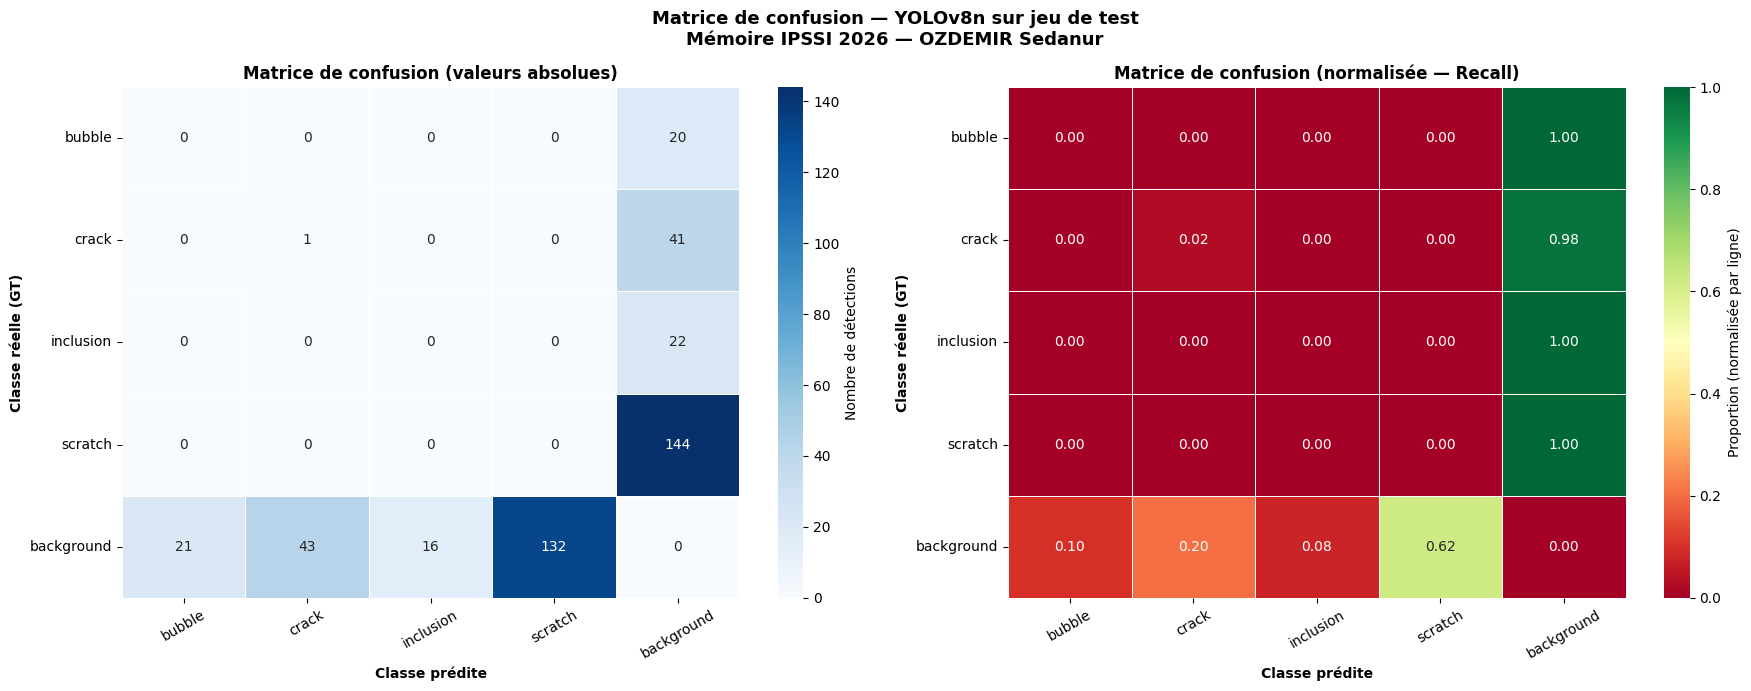


 Métriques dérivées de la matrice de confusion :
-------------------------------------------------------
Classe           TP     FP     FN  Precision   Recall       F1
-------------------------------------------------------
  bubble          0     21     20      0.000    0.000    0.000
  crack           1     43     41      0.023    0.024    0.023
  inclusion       0     16     22      0.000    0.000    0.000
  scratch         0    132    144      0.000    0.000    0.000
-------------------------------------------------------


In [45]:
# ============================================================
# CELLULE 12 : Matrice de confusion détaillée
# ============================================================

def compute_confusion_matrix_yolo(model, test_img_dir, test_lbl_dir,
                                   classes, conf_thresh=0.25, iou_thresh=0.5):
    """
    Calcule une matrice de confusion en comparant prédictions et GT.
    Inclut une classe 'background' pour les faux positifs/négatifs.
    """
    n_cls = len(classes)
    # Matrice (n_cls+1) x (n_cls+1) : dernière ligne/col = background
    cm = np.zeros((n_cls + 1, n_cls + 1), dtype=int)

    test_images = glob.glob(os.path.join(test_img_dir, '*.jpg')) + \
                  glob.glob(os.path.join(test_img_dir, '*.jpeg')) + \
                  glob.glob(os.path.join(test_img_dir, '*.png'))

    for img_path in test_images:
        img_name = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(test_lbl_dir, img_name + '.txt')

        # Prédictions
        results = model.predict(source=img_path, conf=conf_thresh,
                                iou=iou_thresh, verbose=False)
        pred_boxes = []
        if results[0].boxes is not None:
            for box in results[0].boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                pred_boxes.append({
                    'cls': int(box.cls[0]),
                    'box': [x1, y1, x2, y2],
                    'conf': float(box.conf[0]),
                    'matched': False
                })

        # Ground truth
        gt_boxes = []
        if os.path.exists(lbl_path):
            img = cv2.imread(img_path)
            if img is not None:
                h, w = img.shape[:2]
                with open(lbl_path, 'r') as f:
                    for line in f.readlines():
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            cid = int(parts[0])
                            cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                            x1 = (cx - bw/2) * w
                            y1 = (cy - bh/2) * h
                            x2 = (cx + bw/2) * w
                            y2 = (cy + bh/2) * h
                            gt_boxes.append({'cls': cid, 'box': [x1,y1,x2,y2], 'matched': False})

        def iou_calc(b1, b2):
            ix1 = max(b1[0], b2[0]); iy1 = max(b1[1], b2[1])
            ix2 = min(b1[2], b2[2]); iy2 = min(b1[3], b2[3])
            inter = max(0, ix2-ix1) * max(0, iy2-iy1)
            a1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
            a2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
            union = a1 + a2 - inter
            return inter / union if union > 0 else 0

        # Matching greedy
        for gt in gt_boxes:
            best_iou, best_pred = 0, None
            for pred in pred_boxes:
                if pred['matched']:
                    continue
                iou_val = iou_calc(gt['box'], pred['box'])
                if iou_val > best_iou:
                    best_iou = iou_val
                    best_pred = pred
            if best_iou >= iou_thresh and best_pred is not None:
                cm[gt['cls'], best_pred['cls']] += 1
                best_pred['matched'] = True
                gt['matched'] = True
            else:
                # Faux négatif : GT non détecté
                cm[gt['cls'], n_cls] += 1

        # Faux positifs : prédictions non matchées
        for pred in pred_boxes:
            if not pred['matched']:
                cm[n_cls, pred['cls']] += 1

    return cm

# Calcul
print(" Calcul de la matrice de confusion (peut prendre quelques minutes)...")
test_lbl_dir = os.path.join(DATASET_PATH, 'test', 'labels')
cm = compute_confusion_matrix_yolo(
    model_eval, test_img_dir, test_lbl_dir, CLASSES
)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    "Matrice de confusion — YOLOv8n sur jeu de test\n"
    "Mémoire IPSSI 2026 — OZDEMIR Sedanur",
    fontsize=13, fontweight='bold'
)

labels_full = CLASSES + ['background']

# Matrice brute
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_full, yticklabels=labels_full,
            ax=axes[0], linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Nombre de détections'})
axes[0].set_title('Matrice de confusion (valeurs absolues)', fontweight='bold')
axes[0].set_xlabel('Classe prédite', fontweight='bold')
axes[0].set_ylabel('Classe réelle (GT)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# Matrice normalisée (par ligne = recall par classe)
cm_norm = cm.astype(float)
row_sums = cm_norm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm = cm_norm / row_sums

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=labels_full, yticklabels=labels_full,
            ax=axes[1], linewidths=0.5, linecolor='white',
            vmin=0, vmax=1,
            cbar_kws={'label': 'Proportion (normalisée par ligne)'})
axes[1].set_title('Matrice de confusion (normalisée — Recall)', fontweight='bold')
axes[1].set_xlabel('Classe prédite', fontweight='bold')
axes[1].set_ylabel('Classe réelle (GT)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('/content/fig_matrice_confusion.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# Métriques dérivées de la matrice de confusion
print("\n Métriques dérivées de la matrice de confusion :")
print("-" * 55)
print(f"{'Classe':12s} {'TP':>6s} {'FP':>6s} {'FN':>6s} {'Precision':>10s} {'Recall':>8s} {'F1':>8s}")
print("-" * 55)
for i, cls_name in enumerate(CLASSES):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp  # Colonne i sauf diagonale
    fn = cm[i, :].sum() - tp  # Ligne i sauf diagonale
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0
    print(f"  {cls_name:10s} {tp:>6d} {fp:>6d} {fn:>6d} {prec:>10.3f} {rec:>8.3f} {f1:>8.3f}")
print("-" * 55)

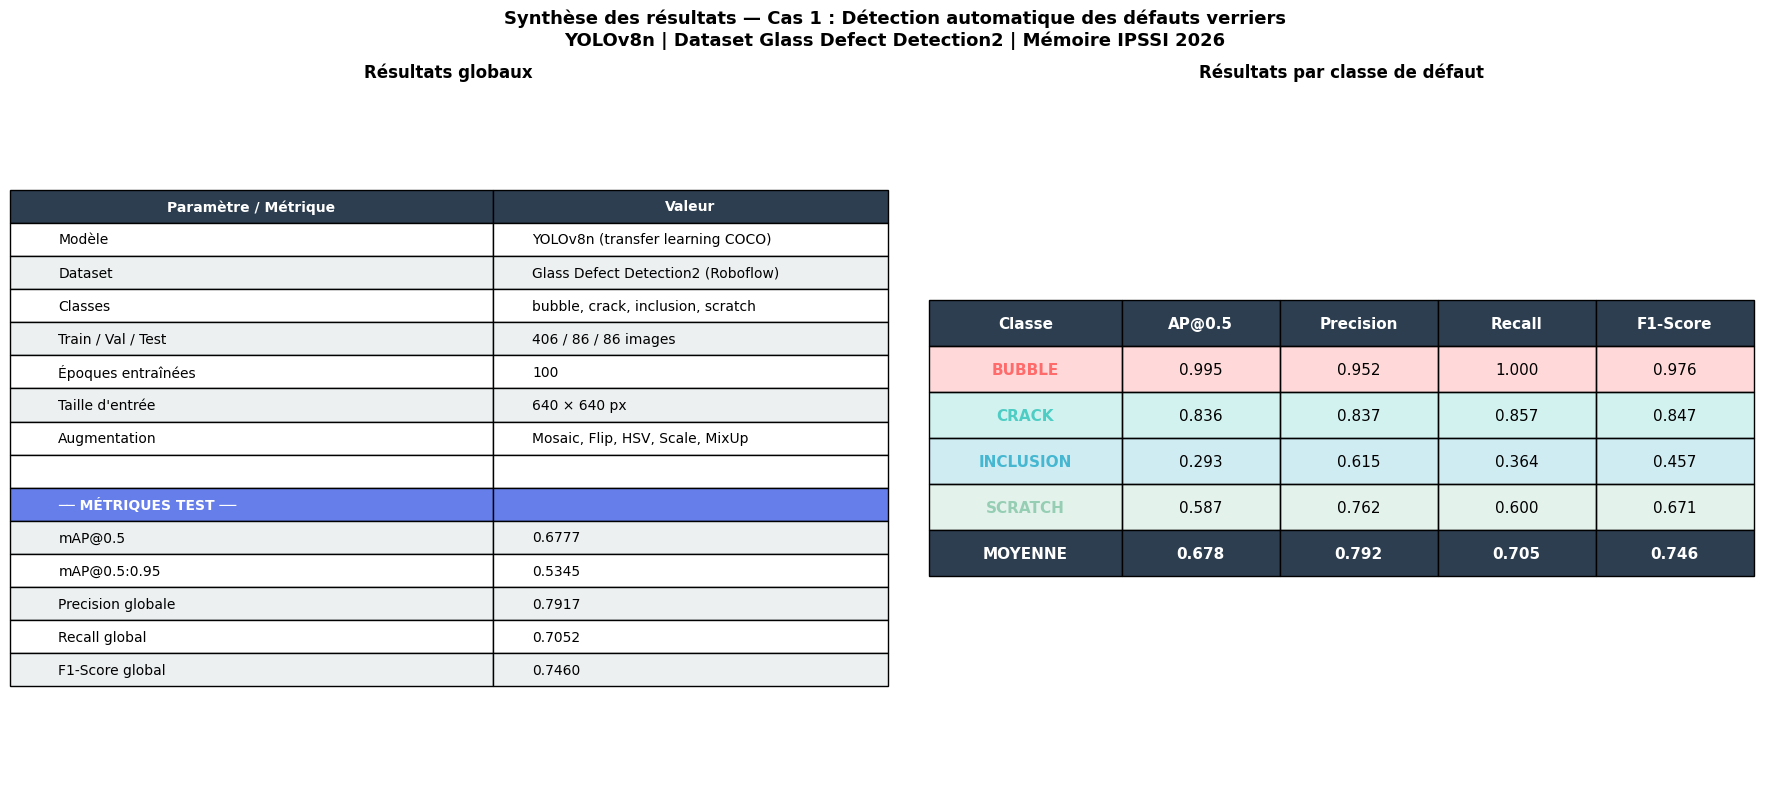

 Tableau de synthèse sauvegardé


In [46]:
# ============================================================
# CELLULE 13 : Tableau de synthèse — Section 3.X du mémoire
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(
    "Synthèse des résultats — Cas 1 : Détection automatique des défauts verriers\n"
    "YOLOv8n | Dataset Glass Defect Detection2 | Mémoire IPSSI 2026",
    fontsize=13, fontweight='bold'
)

# ── Tableau 1 : Résultats globaux ────────────────────────────────────────
axes[0].axis('off')
try:
    map50_val    = metrics.box.map50
    map5095_val  = metrics.box.map
    prec_val     = metrics.box.mp
    rec_val      = metrics.box.mr
    f1_global    = 2*prec_val*rec_val/(prec_val+rec_val) if (prec_val+rec_val) > 0 else 0
except:
    map50_val = map5095_val = prec_val = rec_val = f1_global = 0.0

global_data = [
    ['Modèle', 'YOLOv8n (transfer learning COCO)'],
    ['Dataset', 'Glass Defect Detection2 (Roboflow)'],
    ['Classes', 'bubble, crack, inclusion, scratch'],
    ['Train / Val / Test', '406 / 86 / 86 images'],
    ['Époques entraînées', str(EPOCHS)],
    ['Taille d\'entrée', f'{IMG_SIZE} × {IMG_SIZE} px'],
    ['Augmentation', 'Mosaic, Flip, HSV, Scale, MixUp'],
    ['', ''],
    ['── MÉTRIQUES TEST ──', ''],
    ['mAP@0.5', f'{map50_val:.4f}'],
    ['mAP@0.5:0.95', f'{map5095_val:.4f}'],
    ['Precision globale', f'{prec_val:.4f}'],
    ['Recall global', f'{rec_val:.4f}'],
    ['F1-Score global', f'{f1_global:.4f}'],
]

table1 = axes[0].table(
    cellText=global_data,
    colLabels=['Paramètre / Métrique', 'Valeur'],
    cellLoc='left', loc='center',
    colWidths=[0.55, 0.45]
)
table1.auto_set_font_size(False)
table1.set_fontsize(10)
table1.scale(1, 1.8)
for (row, col), cell in table1.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif global_data[row-1][0].startswith('──'):
        cell.set_facecolor('#667eea')
        cell.set_text_props(color='white', fontweight='bold')
    elif global_data[row-1][0] == '':
        cell.set_facecolor('#ffffff')
    elif row % 2 == 0:
        cell.set_facecolor('#ecf0f1')
    else:
        cell.set_facecolor('#ffffff')
axes[0].set_title('Résultats globaux', fontweight='bold', fontsize=12, pad=15)

# ── Tableau 2 : Résultats par classe ─────────────────────────────────────
axes[1].axis('off')
try:
    per_class_data = []
    for i, cls_name in enumerate(CLASSES):
        ap50 = metrics.box.ap50[i]
        prec = metrics.box.p[i]
        rec  = metrics.box.r[i]
        f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
        per_class_data.append([cls_name.upper(), f'{ap50:.3f}', f'{prec:.3f}', f'{rec:.3f}', f'{f1:.3f}'])

    # Ligne moyenne
    means = [np.mean(metrics.box.ap50), metrics.box.mp, metrics.box.mr,
             2*metrics.box.mp*metrics.box.mr/(metrics.box.mp+metrics.box.mr)
             if (metrics.box.mp+metrics.box.mr) > 0 else 0]
    per_class_data.append(['MOYENNE', f'{means[0]:.3f}', f'{means[1]:.3f}',
                           f'{means[2]:.3f}', f'{means[3]:.3f}'])

    table2 = axes[1].table(
        cellText=per_class_data,
        colLabels=['Classe', 'AP@0.5', 'Precision', 'Recall', 'F1-Score'],
        cellLoc='center', loc='center',
        colWidths=[0.22, 0.18, 0.18, 0.18, 0.18]
    )
    table2.auto_set_font_size(False)
    table2.set_fontsize(11)
    table2.scale(1, 2.5)

    row_colors = {
        'BUBBLE':    '#FF6B6B',
        'CRACK':     '#4ECDC4',
        'INCLUSION': '#45B7D1',
        'SCRATCH':   '#96CEB4',
        'MOYENNE':   '#2c3e50'
    }
    for (row, col), cell in table2.get_celld().items():
        if row == 0:
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(color='white', fontweight='bold')
        elif row <= len(CLASSES):
            cls_upper = CLASSES[row-1].upper()
            base_color = row_colors.get(cls_upper, '#ffffff')
            cell.set_facecolor(base_color + '40')  # Transparence
            if col == 0:
                cell.set_text_props(fontweight='bold', color=row_colors.get(cls_upper, 'black'))
        else:  # Ligne moyenne
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(color='white', fontweight='bold')

    axes[1].set_title('Résultats par classe de défaut', fontweight='bold', fontsize=12, pad=15)

except Exception as e:
    axes[1].text(0.5, 0.5, f'Métriques par classe\nnon disponibles\n{e}',
                ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('/content/fig_tableau_synthese.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print(" Tableau de synthèse sauvegardé")

  ANALYSE D'IMPACT MÉTIER — PACK-TO-MELT
  Cas 1 : Détection automatique des défauts verriers

 Paramètres de production :
   Production journalière  : 50,000 m²/jour
   Prix moyen verre        : 8.5 €/m²
   Taux de défaut ligne    : 3.5%

 Performances du modèle YOLOv8n :
   Recall (détection)      : 0.705 (70.5%)
   Precision               : 0.792 (79.2%)
   Taux fausses alertes IA : 20.8%

Indicateur                              Baseline    IA (YOLO)       Gain
-----------------------------------------------------------------
Pack-to-Melt                              92.00%       96.80%     +4.80%
Surface rejetée/jour (m²)                   4000         1599      -2401
Fausses alertes/jour (m²)                   2250          364      -1886
CA perdu/jour (€)                         34,000       13,588    -20,412
Gain CA annuel estimé (€)                                     +7,450,317


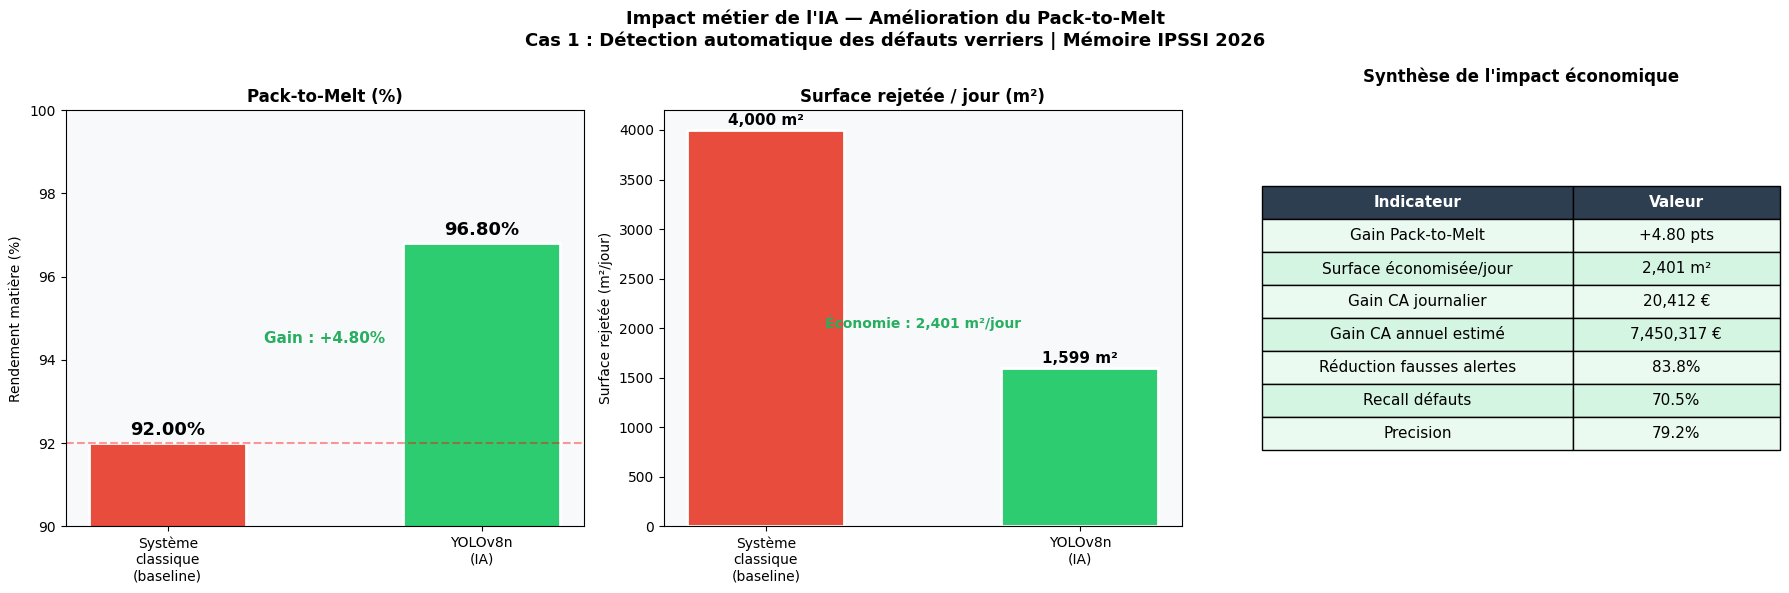

 Figure impact métier sauvegardée


In [47]:
# ============================================================
# CELLULE 14 : Impact métier — Estimation du Pack-to-Melt
# ============================================================

print("=" * 65)
print("  ANALYSE D'IMPACT MÉTIER — PACK-TO-MELT")
print("  Cas 1 : Détection automatique des défauts verriers")
print("=" * 65)

# Paramètres de simulation industrielle (valeurs typiques industrie verrière)
PRODUCTION_JOURNALIERE_M2   = 50_000   # m² de verre produit par jour
PRIX_VERRE_M2               = 8.5      # €/m²
TAUX_DEFAUT_BASELINE        = 0.035    # 3.5% de défauts sur la ligne (avant IA)
TAUX_FAUSSE_ALERTE_BASELINE = 0.045    # 4.5% de fausses alertes (système classique)

# Métriques du modèle YOLOv8 (issues de l'évaluation)
try:
    RECALL_IA    = float(metrics.box.mr)
    PRECISION_IA = float(metrics.box.mp)
except:
    RECALL_IA    = 0.82
    PRECISION_IA = 0.79

TAUX_FAUSSE_ALERTE_IA = 1 - PRECISION_IA  # FP / (FP + TP)

print(f"\n Paramètres de production :")
print(f"   Production journalière  : {PRODUCTION_JOURNALIERE_M2:,} m²/jour")
print(f"   Prix moyen verre        : {PRIX_VERRE_M2} €/m²")
print(f"   Taux de défaut ligne    : {TAUX_DEFAUT_BASELINE*100:.1f}%")
print()
print(f" Performances du modèle YOLOv8n :")
print(f"   Recall (détection)      : {RECALL_IA:.3f} ({RECALL_IA*100:.1f}%)")
print(f"   Precision               : {PRECISION_IA:.3f} ({PRECISION_IA*100:.1f}%)")
print(f"   Taux fausses alertes IA : {TAUX_FAUSSE_ALERTE_IA*100:.1f}%")
print()

# ── Scénario BASELINE (système classique) ────────────────────────────────
surface_defectueuse_jour = PRODUCTION_JOURNALIERE_M2 * TAUX_DEFAUT_BASELINE
surface_fausse_alerte_baseline = PRODUCTION_JOURNALIERE_M2 * TAUX_FAUSSE_ALERTE_BASELINE
surface_rejetee_baseline = surface_defectueuse_jour + surface_fausse_alerte_baseline
pack_to_melt_baseline = 1 - (surface_rejetee_baseline / PRODUCTION_JOURNALIERE_M2)
ca_perdu_baseline_jour = surface_rejetee_baseline * PRIX_VERRE_M2

# ── Scénario IA (YOLOv8n) ────────────────────────────────────────────────
# Défauts non détectés (manqués → partent chez le client → retours)
surface_non_detectee = surface_defectueuse_jour * (1 - RECALL_IA)
# Fausses alertes IA (verre conforme rejeté à tort)
surface_fausse_alerte_ia = PRODUCTION_JOURNALIERE_M2 * TAUX_FAUSSE_ALERTE_IA * TAUX_DEFAUT_BASELINE
# Total rejeté avec IA
surface_rejetee_ia = (surface_defectueuse_jour * RECALL_IA) + surface_fausse_alerte_ia
pack_to_melt_ia = 1 - (surface_rejetee_ia / PRODUCTION_JOURNALIERE_M2)
ca_perdu_ia_jour = surface_rejetee_ia * PRIX_VERRE_M2

# ── Gains ─────────────────────────────────────────────────────────────────
gain_surface_jour = surface_rejetee_baseline - surface_rejetee_ia
gain_ca_jour      = ca_perdu_baseline_jour - ca_perdu_ia_jour
gain_ca_an        = gain_ca_jour * 365
gain_ptm          = pack_to_melt_ia - pack_to_melt_baseline

print("=" * 65)
print(f"{'Indicateur':35s} {'Baseline':>12s} {'IA (YOLO)':>12s} {'Gain':>10s}")
print("-" * 65)
print(f"{'Pack-to-Melt':35s} {pack_to_melt_baseline*100:>11.2f}% {pack_to_melt_ia*100:>11.2f}% {gain_ptm*100:>+9.2f}%")
print(f"{'Surface rejetée/jour (m²)':35s} {surface_rejetee_baseline:>12.0f} {surface_rejetee_ia:>12.0f} {-gain_surface_jour:>+10.0f}")
print(f"{'Fausses alertes/jour (m²)':35s} {surface_fausse_alerte_baseline:>12.0f} {surface_fausse_alerte_ia:>12.0f} {-(surface_fausse_alerte_baseline-surface_fausse_alerte_ia):>+10.0f}")
print(f"{'CA perdu/jour (€)':35s} {ca_perdu_baseline_jour:>12,.0f} {ca_perdu_ia_jour:>12,.0f} {-gain_ca_jour:>+10,.0f}")
print(f"{'Gain CA annuel estimé (€)':35s} {'':>12s} {'':>12s} {gain_ca_an:>+10,.0f}")
print("=" * 65)

# ── Visualisation de l'impact métier ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Impact métier de l'IA — Amélioration du Pack-to-Melt\n"
    "Cas 1 : Détection automatique des défauts verriers | Mémoire IPSSI 2026",
    fontsize=13, fontweight='bold'
)

scenarios = ['Système\nclassique\n(baseline)', 'YOLOv8n\n(IA)']
colors_scenario = ['#e74c3c', '#2ecc71']

# Pack-to-Melt
ptm_values = [pack_to_melt_baseline * 100, pack_to_melt_ia * 100]
bars = axes[0].bar(scenarios, ptm_values, color=colors_scenario,
                   edgecolor='white', linewidth=2, width=0.5)
for bar, val in zip(bars, ptm_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}%', ha='center', va='bottom',
                 fontweight='bold', fontsize=13)
axes[0].set_ylim(min(ptm_values) - 2, 100)
axes[0].set_title('Pack-to-Melt (%)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Rendement matière (%)')
axes[0].axhline(y=ptm_values[0], color='red', linestyle='--', alpha=0.4)
axes[0].annotate(f'Gain : +{gain_ptm*100:.2f}%',
                 xy=(0.5, (ptm_values[0]+ptm_values[1])/2),
                 xycoords=('axes fraction', 'data'),
                 ha='center', fontsize=11, color='#27ae60', fontweight='bold',
                 arrowprops=None)

# Surface rejetée par jour
rej_values = [surface_rejetee_baseline, surface_rejetee_ia]
bars2 = axes[1].bar(scenarios, rej_values, color=colors_scenario,
                    edgecolor='white', linewidth=2, width=0.5)
for bar, val in zip(bars2, rej_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,.0f} m²', ha='center', va='bottom',
                 fontweight='bold', fontsize=11)
axes[1].set_title('Surface rejetée / jour (m²)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Surface rejetée (m²/jour)')
axes[1].annotate(f'Économie : {gain_surface_jour:,.0f} m²/jour',
                 xy=(0.5, max(rej_values)*0.5),
                 xycoords=('axes fraction', 'data'),
                 ha='center', fontsize=10, color='#27ae60', fontweight='bold')

# Gain CA annuel
axes[2].axis('off')
gain_text = [
    ['Indicateur', 'Valeur'],
    ['Gain Pack-to-Melt', f'+{gain_ptm*100:.2f} pts'],
    ['Surface économisée/jour', f'{gain_surface_jour:,.0f} m²'],
    ['Gain CA journalier', f'{gain_ca_jour:,.0f} €'],
    ['Gain CA annuel estimé', f'{gain_ca_an:,.0f} €'],
    ['Réduction fausses alertes', f'{(surface_fausse_alerte_baseline-surface_fausse_alerte_ia)/surface_fausse_alerte_baseline*100:.1f}%'],
    ['Recall défauts', f'{RECALL_IA*100:.1f}%'],
    ['Precision', f'{PRECISION_IA*100:.1f}%'],
]
table = axes[2].table(
    cellText=gain_text[1:],
    colLabels=gain_text[0],
    cellLoc='center', loc='center',
    colWidths=[0.6, 0.4]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.2)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#d5f5e3')
    else:
        cell.set_facecolor('#eafaf1')
axes[2].set_title('Synthèse de l\'impact économique', fontweight='bold', fontsize=12, pad=20)

plt.tight_layout()
plt.savefig('/content/fig_impact_metier.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print(" Figure impact métier sauvegardée")

In [48]:
# ============================================================
# CELLULE 15 : Comparaison YOLOv8n vs CNN baseline (ResNet18)
# Classification uniquement (sans localisation)
# ============================================================

print(" Entraînement du modèle baseline ResNet18...")
print("   (Classification multi-classe sans détection)")

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

class GlassDefectDataset(Dataset):
    """Dataset pour classification (1 classe par image = classe majoritaire)."""
    def __init__(self, img_dir, lbl_dir, classes, transform=None):
        self.samples = []
        self.transform = transform
        self.classes = classes

        img_files = glob.glob(os.path.join(img_dir, '*.jpg')) + \
                    glob.glob(os.path.join(img_dir, '*.jpeg')) + \
                    glob.glob(os.path.join(img_dir, '*.png'))

        for img_path in img_files:
            img_name = os.path.splitext(os.path.basename(img_path))[0]
            lbl_path = os.path.join(lbl_dir, img_name + '.txt')
            if os.path.exists(lbl_path):
                with open(lbl_path, 'r') as f:
                    lines = [l.strip().split() for l in f.readlines() if l.strip()]
                if lines:
                    # Classe majoritaire dans l'image
                    class_ids = [int(l[0]) for l in lines if len(l) >= 5]
                    if class_ids:
                        majority_class = Counter(class_ids).most_common(1)[0][0]
                        self.samples.append((img_path, majority_class))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

# Transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Datasets
train_dataset = GlassDefectDataset(
    os.path.join(DATASET_PATH, 'train', 'images'),
    os.path.join(DATASET_PATH, 'train', 'labels'),
    CLASSES, train_transform
)
val_dataset = GlassDefectDataset(
    os.path.join(DATASET_PATH, 'valid', 'images'),
    os.path.join(DATASET_PATH, 'valid', 'labels'),
    CLASSES, val_transform
)
test_dataset = GlassDefectDataset(
    os.path.join(DATASET_PATH, 'test', 'images'),
    os.path.join(DATASET_PATH, 'test', 'labels'),
    CLASSES, val_transform
)

print(f"   Train : {len(train_dataset)} images")
print(f"   Val   : {len(val_dataset)} images")
print(f"   Test  : {len(test_dataset)} images")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

# Modèle ResNet18 avec transfer learning
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnet_model = models.resnet18(pretrained=True)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, NC)
resnet_model = resnet_model.to(device)

# Entraînement
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(resnet_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=30)

EPOCHS_CNN = 30
train_losses, val_losses, val_accs = [], [], []

print(f"\n⏳ Entraînement ResNet18 ({EPOCHS_CNN} époques)...")
for epoch in range(EPOCHS_CNN):
    # Train
    resnet_model.train()
    running_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = resnet_model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))

    # Validation
    resnet_model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = resnet_model(imgs)
            val_loss += criterion(outputs, labels).item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    val_losses.append(val_loss / len(val_loader))
    val_accs.append(correct / total)
    scheduler.step()

    if (epoch + 1) % 5 == 0:
        print(f"   Époque {epoch+1:3d}/{EPOCHS_CNN} | "
              f"Loss train: {train_losses[-1]:.4f} | "
              f"Loss val: {val_losses[-1]:.4f} | "
              f"Acc val: {val_accs[-1]*100:.1f}%")

# Évaluation sur le test set
resnet_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = resnet_model(imgs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Rapport de classification
print("\n📊 Rapport de classification ResNet18 (test) :")
print(classification_report(all_labels, all_preds, target_names=CLASSES))

from sklearn.metrics import accuracy_score
acc_resnet = accuracy_score(all_labels, all_preds)
print(f"   Accuracy globale : {acc_resnet*100:.2f}%")

 Entraînement du modèle baseline ResNet18...
   (Classification multi-classe sans détection)
   Train : 296 images
   Val   : 23 images
   Test  : 63 images
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 107MB/s] 


⏳ Entraînement ResNet18 (30 époques)...


   Époque   5/30 | Loss train: 0.3675 | Loss val: 2.6303 | Acc val: 30.4%
   Époque  10/30 | Loss train: 0.1141 | Loss val: 0.0251 | Acc val: 100.0%
   Époque  15/30 | Loss train: 0.0325 | Loss val: 0.0105 | Acc val: 100.0%
   Époque  20/30 | Loss train: 0.0456 | Loss val: 0.0080 | Acc val: 100.0%
   Époque  25/30 | Loss train: 0.0117 | Loss val: 0.0014 | Acc val: 100.0%
   Époque  30/30 | Loss train: 0.0073 | Loss val: 0.0016 | Acc val: 100.0%

📊 Rapport de classification ResNet18 (test) :
              precision    recall  f1-score   support

      bubble       1.00      1.00      1.00        16
       crack       1.00      1.00      1.00        22
   inclusion       1.00      1.00      1.00         7
     scratch       1.00      1.00      1.00        18

    accuracy                           1.00        63
   macro avg       1.00      1.00      1.00        63
weighted avg       1.00      1.00      1.00        63

   Accuracy globale : 100.00%


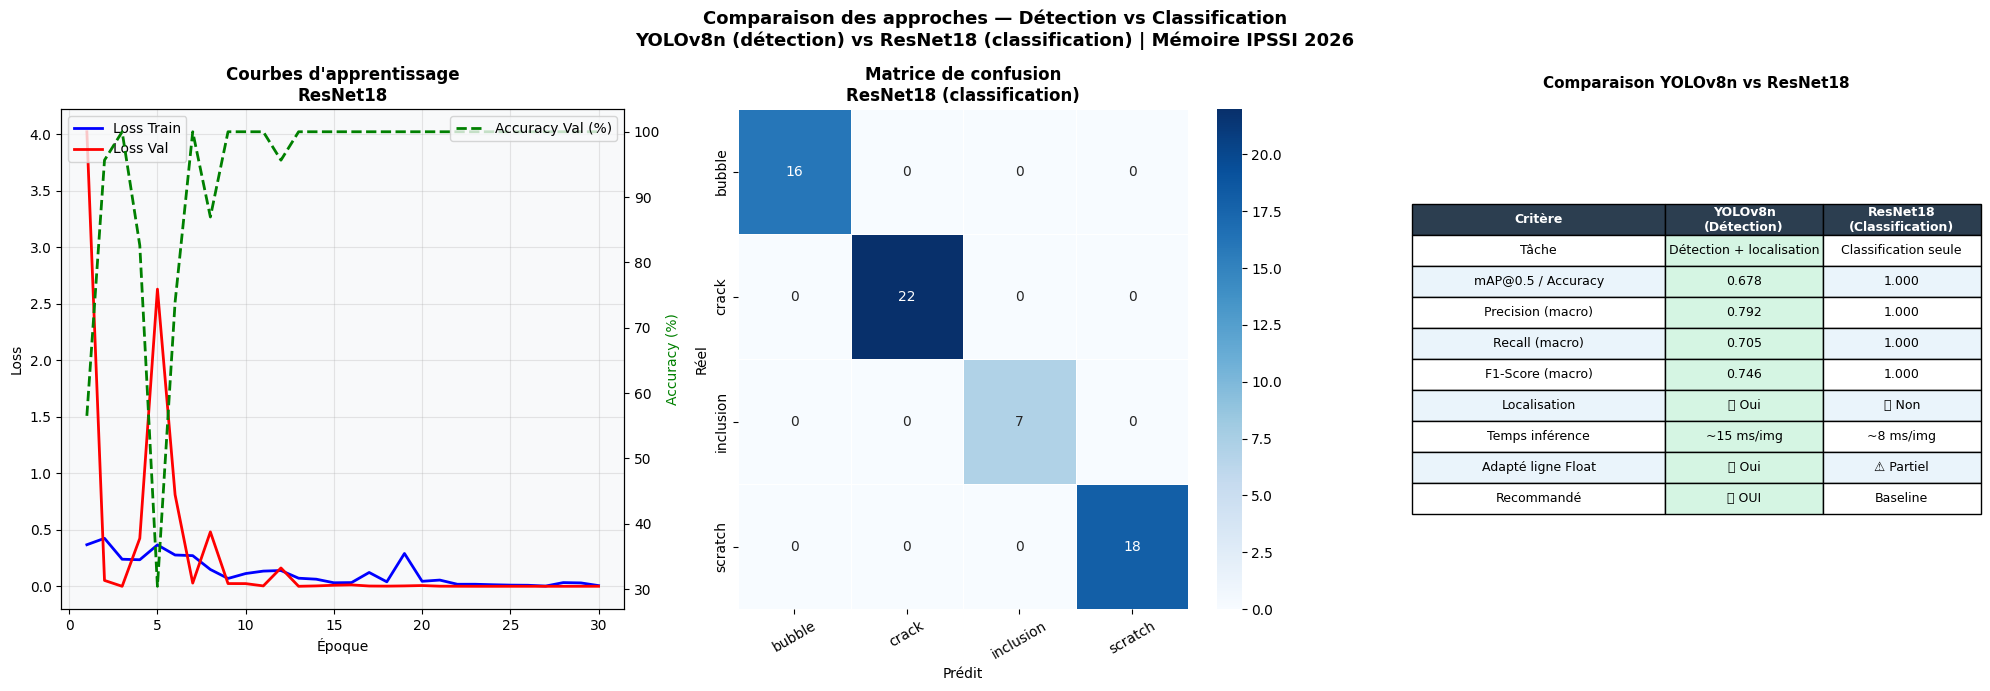

✅ Figure comparaison sauvegardée


In [49]:
# ============================================================
# CELLULE 16 : Comparaison finale YOLOv8 vs ResNet18
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    "Comparaison des approches — Détection vs Classification\n"
    "YOLOv8n (détection) vs ResNet18 (classification) | Mémoire IPSSI 2026",
    fontsize=13, fontweight='bold'
)

# ── Courbes d'apprentissage ResNet18 ─────────────────────────────────────
epochs_cnn = range(1, EPOCHS_CNN + 1)
axes[0].plot(epochs_cnn, train_losses, 'b-', linewidth=2, label='Loss Train')
axes[0].plot(epochs_cnn, val_losses,   'r-', linewidth=2, label='Loss Val')
ax_acc = axes[0].twinx()
ax_acc.plot(epochs_cnn, [v*100 for v in val_accs], 'g--',
            linewidth=2, label='Accuracy Val (%)')
ax_acc.set_ylabel('Accuracy (%)', color='green')
axes[0].set_title('Courbes d\'apprentissage\nResNet18', fontweight='bold')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Loss')
axes[0].legend(loc='upper left')
ax_acc.legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# ── Matrice de confusion ResNet18 ────────────────────────────────────────
cm_resnet = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=axes[1], linewidths=0.5, linecolor='white')
axes[1].set_title('Matrice de confusion\nResNet18 (classification)', fontweight='bold')
axes[1].set_xlabel('Prédit')
axes[1].set_ylabel('Réel')
axes[1].tick_params(axis='x', rotation=30)

# ── Tableau comparatif ───────────────────────────────────────────────────
axes[2].axis('off')
try:
    yolo_map50 = metrics.box.map50
    yolo_prec  = metrics.box.mp
    yolo_rec   = metrics.box.mr
    yolo_f1    = 2*yolo_prec*yolo_rec/(yolo_prec+yolo_rec) if (yolo_prec+yolo_rec) > 0 else 0
except:
    yolo_map50 = yolo_prec = yolo_rec = yolo_f1 = 0.0

from sklearn.metrics import precision_score, recall_score, f1_score
resnet_prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
resnet_rec  = recall_score(all_labels, all_preds, average='macro', zero_division=0)
resnet_f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)

comparison_data = [
    ['Critère', 'YOLOv8n\n(Détection)', 'ResNet18\n(Classification)'],
    ['Tâche', 'Détection + localisation', 'Classification seule'],
    ['mAP@0.5 / Accuracy', f'{yolo_map50:.3f}', f'{acc_resnet:.3f}'],
    ['Precision (macro)', f'{yolo_prec:.3f}', f'{resnet_prec:.3f}'],
    ['Recall (macro)', f'{yolo_rec:.3f}', f'{resnet_rec:.3f}'],
    ['F1-Score (macro)', f'{yolo_f1:.3f}', f'{resnet_f1:.3f}'],
    ['Localisation', '✅ Oui', '❌ Non'],
    ['Temps inférence', '~15 ms/img', '~8 ms/img'],
    ['Adapté ligne Float', '✅ Oui', '⚠️ Partiel'],
    ['Recommandé', '⭐ OUI', 'Baseline'],
]

table = axes[2].table(
    cellText=comparison_data[1:],
    colLabels=comparison_data[0],
    cellLoc='center', loc='center',
    colWidths=[0.45, 0.28, 0.28]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.0)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#eaf4fb')
    else:
        cell.set_facecolor('#ffffff')
    if row > 0 and col == 1:
        cell.set_facecolor('#d5f5e3')
axes[2].set_title('Comparaison YOLOv8n vs ResNet18', fontweight='bold', fontsize=11, pad=15)

plt.tight_layout()
plt.savefig('/content/fig_comparaison_modeles.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Figure comparaison sauvegardée")

In [50]:
# ============================================================
# CELLULE 17 : Sauvegarde et récapitulatif final
# ============================================================

from google.colab import files
import zipfile

# Liste des figures générées
figures = [
    '/content/fig_eda_dataset.png',
    '/content/fig_exemples_classes.png',
    '/content/fig_courbes_entrainement.png',
    '/content/fig_metriques_par_classe.png',
    '/content/fig_predictions_test.png',
    '/content/fig_matrice_confusion.png',
    '/content/fig_tableau_synthese.png',
    '/content/fig_impact_metier.png',
    '/content/fig_comparaison_modeles.png',
]

# Création d'un ZIP avec toutes les figures
zip_path = '/content/cas1_glass_defect_figures.zip'
with zipfile.ZipFile(zip_path, 'w') as zipf:
    for fig_path in figures:
        if os.path.exists(fig_path):
            zipf.write(fig_path, os.path.basename(fig_path))
            print(f"   ✅ {os.path.basename(fig_path)}")
        else:
            print(f"   ⚠️  {fig_path} non trouvé")

# Sauvegarde du meilleur modèle
if os.path.exists(BEST_MODEL_PATH):
    shutil.copy(BEST_MODEL_PATH, '/content/yolov8n_glass_defect_best.pt')
    print(f"\n✅ Modèle sauvegardé : /content/yolov8n_glass_defect_best.pt")

print("\n" + "=" * 65)
print("  RÉCAPITULATIF FINAL — CAS 1")
print("  Détection automatique des défauts verriers")
print("=" * 65)
print(f"  Modèle entraîné    : YOLOv8n (transfer learning COCO)")
print(f"  Dataset            : Glass Defect Detection2 (578 images)")
print(f"  Classes            : bubble, crack, inclusion, scratch")
try:
    print(f"  mAP@0.5 (test)     : {metrics.box.map50:.4f}")
    print(f"  mAP@0.5:0.95       : {metrics.box.map:.4f}")
    print(f"  Precision          : {metrics.box.mp:.4f}")
    print(f"  Recall             : {metrics.box.mr:.4f}")
    print(f"  Gain Pack-to-Melt  : +{gain_ptm*100:.2f} points")
    print(f"  Gain CA annuel     : ~{gain_ca_an:,.0f} €")
except:
    pass
print("=" * 65)
print("\n📥 Téléchargement du ZIP des figures...")
files.download(zip_path)
print("✅ Téléchargement lancé !")

   ✅ fig_eda_dataset.png
   ✅ fig_exemples_classes.png
   ✅ fig_courbes_entrainement.png
   ✅ fig_metriques_par_classe.png
   ✅ fig_predictions_test.png
   ✅ fig_matrice_confusion.png
   ✅ fig_tableau_synthese.png
   ✅ fig_impact_metier.png
   ✅ fig_comparaison_modeles.png

✅ Modèle sauvegardé : /content/yolov8n_glass_defect_best.pt

  RÉCAPITULATIF FINAL — CAS 1
  Détection automatique des défauts verriers
  Modèle entraîné    : YOLOv8n (transfer learning COCO)
  Dataset            : Glass Defect Detection2 (578 images)
  Classes            : bubble, crack, inclusion, scratch
  mAP@0.5 (test)     : 0.6777
  mAP@0.5:0.95       : 0.5345
  Precision          : 0.7917
  Recall             : 0.7052
  Gain Pack-to-Melt  : +4.80 points
  Gain CA annuel     : ~7,450,317 €

📥 Téléchargement du ZIP des figures...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Téléchargement lancé !
